In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
NUM_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20] 

attn_scores = {}
pca_scores = {}
shap_scores = {}

for layer in NUM_LAYERS:
    df_attn = pd.read_csv(f"Results/attention_scores/{layer}layers/attention_scores{layer}layers_unsorted.csv")
    df_pca = pd.read_csv(f"Results/attention_scores/{layer}layers/pca_scores{layer}layers_unsorted.csv")
    df_shap = pd.read_csv(f"Results/shap_values/tables/{layer}layers/shap_scores{layer}layers_unsorted.csv")

    attn_scores[layer] = df_attn["score"].to_numpy()
    pca_scores[layer] = df_pca["score"].to_numpy()
    shap_scores[layer] = df_shap["score"].to_numpy()    

### Top-k feature importance

In [3]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

/tmp/ipykernel_7646/1314421533.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


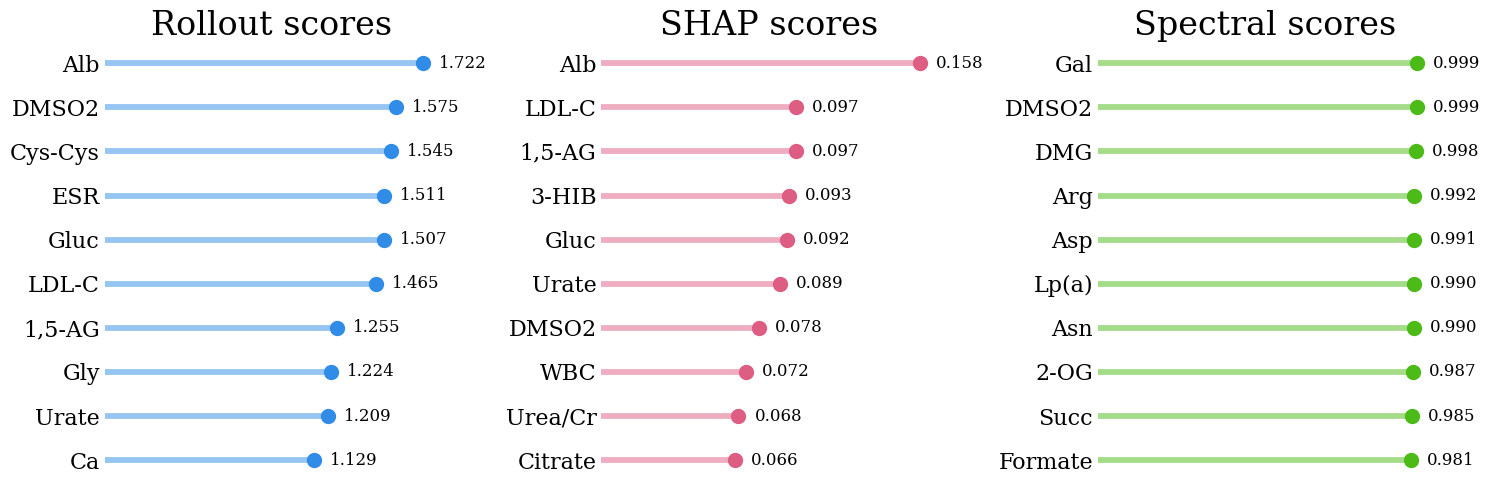

In [6]:
plt.rcParams["font.family"] = "serif"
l = 11

# df_r = pd.read_csv(f"Results/attention_scores/{l}layers/attention_scores{l}layers.csv")
# df_p = pd.read_csv(f"Results/attention_scores/{l}layers/pca_scores{l}layers.csv")
# df_s = pd.read_csv(f"Results/shap_values/tables/{l}layers/shap_scores{l}layers.csv")

df_r = pd.read_csv(f"Results/attention_scores/{l}layers/attention_scores{l}layers_unsorted.csv")
df_p = pd.read_csv(f"Results/feature_rankings/pcs_scores_unsorted.csv")
# df_p = pd.read_csv(f"Results/attention_scores/{l}layers/pca_scores{l}layers_unsorted.csv")
df_s = pd.read_csv(f"Results/shap_values/tables/{l}layers/shap_scores{l}layers_unsorted.csv")

scores_dict = {"Rollout scores": df_r["score"].to_numpy(),
               "SHAP scores": df_s["score"].to_numpy(),
               "Spectral scores": df_p["score"].to_numpy()}

feature_dict = {"Rollout scores": df_r["feature"].values.tolist(),
                "SHAP scores": df_s["feature"].values.tolist(),
                "Spectral scores": df_p["feature"].values.tolist()}

colors_dict = {"Rollout scores": "#318CE7",
               "SHAP scores": "#DE5D83",
               "Spectral scores": "#4CBB17"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

k=10

for ax, (title, scores) in zip(axes, scores_dict.items()):

    # --- Top-k selection ---
    idx = np.argsort(scores)[-k:][::-1]
    top_scores = scores[idx]
    top_features = [feature_abbrev[i] for i in idx]
    # top_features = [feature_dict[title][i] for i in idx]

    # Normalize for visual consistency
    top_scores_norm = top_scores / np.max(top_scores)

    y = np.arange(k)

    # --- Thin horizontal lines ---
    for yi, val in zip(y, top_scores_norm):
        ax.hlines(y=yi, xmin=0, xmax=val, linewidth=4.2, 
                  color=colors_dict[title], alpha=0.5)        
        ax.plot(val, yi, 'o', markersize=10, color=colors_dict[title])

    # --- Labels ---
    ax.set_xticks([])
    ax.set_yticks(y)
    ax.set_yticklabels(top_features, fontsize=16)

    ax.invert_yaxis()

    ax.set_title(title, fontsize=24)

    ax.set_xlim(0, 1.05)

    xmax = top_scores_norm.max()
    for j, value in enumerate(top_scores_norm):        
        ax.text(value + 0.05 * xmax, j, 
                f"{top_scores[j]:.3f}", va="center", 
                fontsize=12)

    # Clean style similar to your figure
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.tick_params(axis='y', length=0)

    ax.grid(False)

plt.tight_layout()

# plt.savefig(f"Results/feature_importance_plots/top{k}scores_L{l}.pdf", bbox_inches="tight")

plt.show()

### Ranking correlation

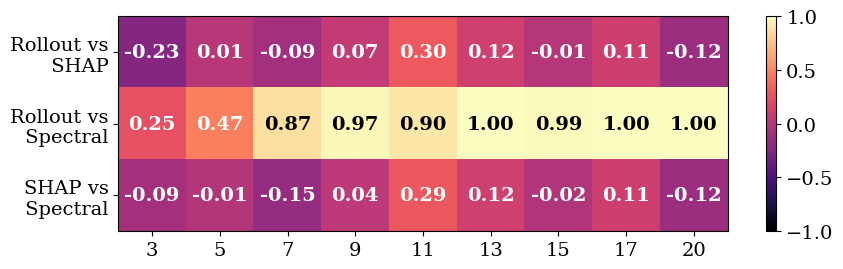

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

corr_rs = []
corr_rp = []
corr_sp = []

topk = 72
cmap = "magma"

for layer in NUM_LAYERS:

    df_r = pd.read_csv(f"Results/attention_scores/{layer}layers/attention_scores{layer}layers.csv")
    df_s = pd.read_csv(f"Results/shap_values/tables/{layer}layers/shap_scores{layer}layers.csv")
    df_p = pd.read_csv(f"Results/attention_scores/{layer}layers/pca_scores{layer}layers.csv")

    r = np.asarray(df_r["original_position"])
    s = np.asarray(df_s["original_position"])
    p = np.asarray(df_p["original_position"])

    corr_rs.append(spearmanr(r[:topk], s[:topk]).correlation)
    corr_rp.append(spearmanr(r[:topk], p[:topk]).correlation)
    corr_sp.append(spearmanr(s[:topk], p[:topk]).correlation)

# Build matrix
heatmap_data = np.array([corr_rs, corr_rp, corr_sp])

fig, ax = plt.subplots(figsize=(9, 2.8))

im = ax.imshow(heatmap_data, aspect="auto", cmap=cmap, 
               vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(range(len(NUM_LAYERS)))
ax.set_xticklabels(NUM_LAYERS, fontsize=14)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Rollout vs\n SHAP", "Rollout vs\n Spectral", "SHAP vs\n Spectral"]
                   , fontsize=14)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):

        value = heatmap_data[i, j]

        # choose text color depending on intensity
        text_color = "white" if abs(value) <= 0.6 else "black"

        ax.text(j, i, f"{value:.2f}", 
                ha="center", va="center", 
                fontsize=14, fontweight="bold",
                color=text_color)

cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label("Spearman correlation")
# ax.set_xlabel("Transformer depth L")

plt.tight_layout()

plt.savefig(f"Results/feature_importance_plots/agreement_top{topk}.pdf", bbox_inches="tight")
plt.show()

### Heatmaps
##### Attention

##### Shap

##### Spectral